In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import spiceypy as spy
import pymcel as pc

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


## Ejercicio 1


In [22]:
# Condiciones iniciales
y0 = 1
t0 = 1
vy = 0

# Parámetros 
T_total = 50
deltat = 0.01
N_steps = int(T_total // deltat)

# Listas para guardar resultados
t_values = np.zeros(N_steps + 1)
y_values = np.zeros(N_steps + 1)

t_values[0] = t0
y_values[0] = y0


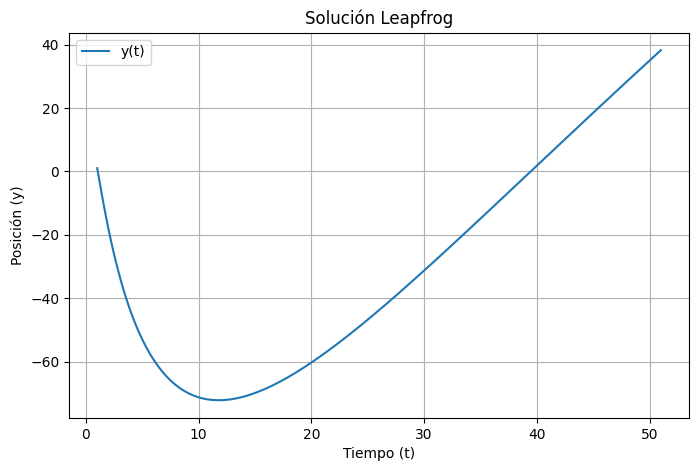

In [32]:
def a(t, y):
    return -y/t**2

v_n = vy
for n in range(N_steps):
    t_n = t_values[n]
    y_n = y_values[n]
    
    # Calculamos la velocidad a medio paso
    v_half = v_n + a(t_n, y_n) * deltat / 2
    
    # Actualizamos la posición e incrementamos el tiempo al paso n+1
    y_values[n+1] = y_n + v_half * deltat    
    t_values[n+1] = t_n + deltat
    
    # Actualizamos la velocidad
    v_n = v_half + a(t_values[n+1], y_values[n+1]) * deltat / 2


plt.figure(figsize=(8, 5))
plt.plot(t_values, y_values, label="y(t)")
plt.xlabel('Tiempo (t)')
plt.ylabel('Posición (y)')
plt.title('Solución Leapfrog')
plt.grid(True)
plt.legend()
plt.show()

## Ejercicio 2

In [34]:
t0 = 0
y0 = 1
vy = 0

T_total = 50
deltat = 0.01
N_steps = int(T_total // deltat)

x_values = np.zeros(N_steps + 1)
y_values = np.zeros(N_steps + 1)

x_values[0] = t0
y_values[0] = y0

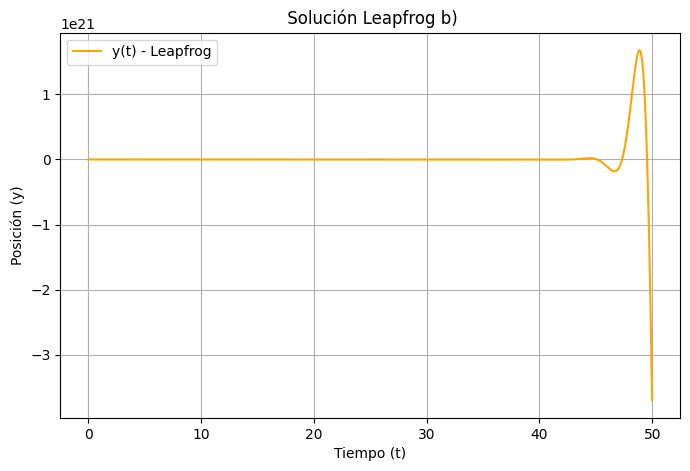

In [ ]:
# Linealizando la EDO

def a(y, v):
    return 2*v - 3*y

v_n = vy

for n in range(N_steps):
    x_n = x_values[n]
    y_n = y_values[n]
    
    # Medio paso de velocidad
    v_half = v_n + a(y_n, v_n) * deltat / 2
    
    # 2. Paso completo de posición
    y_values[n+1] = y_n + v_half * deltat
    x_values[n+1] = x_n + deltat
    
    # Reemplazando en la aceleración para actualizar la velocidad
    v_n = (v_half - 1.5 * deltat * y_values[n+1]) / (1 - deltat)

plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, label="y(t) - Leapfrog", color="orange")
plt.xlabel('Tiempo (t)')
plt.ylabel('Posición (y)')
plt.title(" Solución Leapfrog b)")
plt.grid(True)
plt.legend()
plt.show()

## Ejercicio 3: Péndulo con fricción

La ecuación diferencial es $\ddot{\theta} + b\dot{\theta} + c \sin(\theta) = 0$.  
Despejando, la aceleración es $a = -b\dot{\theta} - c \sin(\theta)$.

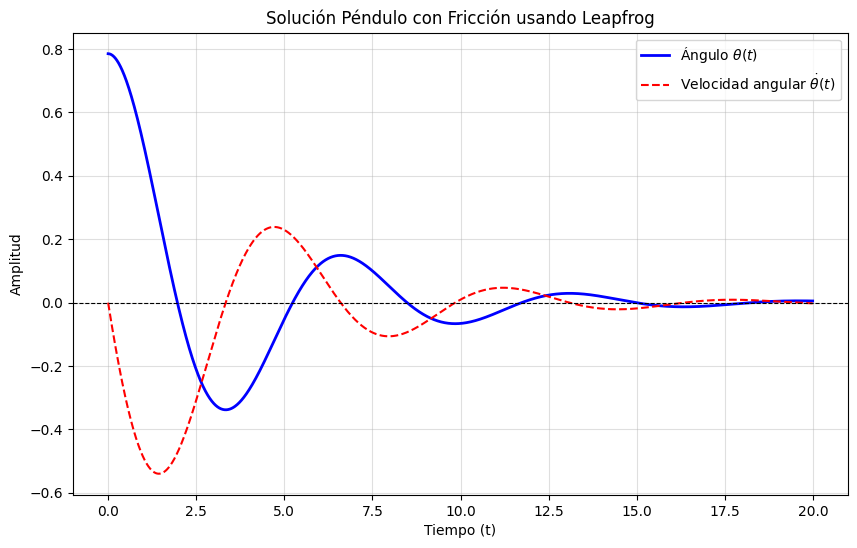

In [ ]:
# Parámetros del péndulo 
b_pend = 0.5
c_pend = 1

# Condiciones iniciales
theta0 = np.pi / 4  # Ángulo inicial de 45 grados
v0_pend = 0.0       # Se suelta desde el reposo
t0_pend = 0.0

# Parámetros de integración
T_total_ = 20
deltat = 0.01
N_steps = int(T_total_ // deltat)

# Registros de datos
t = np.zeros(N_steps + 1)
theta_values = np.zeros(N_steps + 1) # Un arreglo para registrar el ángulo
v_values = np.zeros(N_steps + 1) # Un arreglo para registrar la velocidad

t[0] = t0_pend
theta_values[0] = theta0
v_values[0] = v0_pend

def a_pendulo(theta, v):
    return -b_pend * v - c_pend * np.sin(theta)

v_n_pend = v0_pend

for n in range(N_steps):
    t_n = t[n]
    theta_n = theta_values[n]
    
    v_half = v_n_pend + a_pendulo(theta_n, v_n_pend) * deltat / 2
    
    theta_values[n+1] = theta_n + v_half * deltat
    t[n+1] = t_n + deltat
    
    v_n_pend = (v_half - c_pend * np.sin(theta_values[n+1]) * deltat / 2) / (1 + b_pend * deltat / 2)
    
    v_values[n+1] = v_n_pend


plt.figure(figsize=(10, 6))
plt.plot(t, theta_values, label=r"Ángulo $\theta(t)$", color="blue", linewidth=2)
plt.plot(t, v_values, label=r"Velocidad angular $\dot{\theta}(t)$", color="red", linestyle="dashed")
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.title('Solución Péndulo con Fricción usando Leapfrog')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # Línea en 0 de referencia
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

Donde evidentemente la amplitud tiende a cero ya que se trata de un oscilador amortiguado

## Ejercicio Plano invariable de Laplce

In [ ]:
tef = "2026-04-06 22:00"

spy.furnsh(r"C:\Users\ASUS\Downloads\Mecanica_cel\Mec-nica_Celeste-main\Mec-nica_Celeste\mecanicacelev\Lib\site-packages\pymcel\data\de430.bsp")
spy.furnsh(r"C:\Users\ASUS\Downloads\Mecanica_cel\Mec-nica_Celeste-main\Mec-nica_Celeste\mecanicacelev\Lib\site-packages\pymcel\data\de430.tpc")

# Esta línea es necesaria para obtener la información de los kernels, como el tiempo de luz, que es fundamental para las transformaciones de referencia y cálculos precisos de posiciones y velocidades.
spy.furnsh(r"C:\Users\ASUS\Downloads\Mecanica_cel\Mec-nica_Celeste-main\Mec-nica_Celeste\mecanicacelev\Lib\site-packages\pymcel\data\naif0012.tls")

musol = spy.bodvrd("SUN", "GM", 1)[1][0]
sol, tluz = spy.spkezr("SUN", spy.str2et(tef), "ECLIPJ2000", "NONE", "SSB")

rsol = sol[:3]
vsol = sol[3:]

mujupiter = spy.bodvrd("JUPITER BARYCENTER", "GM", 1)[1][0]
jupiter, tluz = spy.spkezr("JUPITER BARYCENTER", spy.str2et(tef), "ECLIPJ2000", "NONE", "SSB")

rjupiter = jupiter[:3]
vjupiter = jupiter[3:]

musaturno = spy.bodvrd("SATURN BARYCENTER", "GM", 1)[1][0]
saturno, tluz = spy.spkezr("SATURN BARYCENTER", spy.str2et(tef), "ECLIPJ2000", "NONE", "SSB")   

rsaturno = saturno[:3]
vsaturno = saturno[3:]

sol

array([-3.57437506e+05, -8.18549979e+05,  1.76938444e+04,  1.19728909e-02,
        1.94363077e-03, -2.43513418e-04])

In [ ]:
# Ahora calculemos el momentum angular total

G = 6.67e-20  # km^3/kg/s^2 para mantener las unidades consistentes

L = (musol/G * np.cross(rsol, vsol) +
     mujupiter/G * np.cross(rjupiter, vjupiter) +
     musaturno/G * np.cross(rsaturno, vsaturno))

L

array([7.42227872e+35, 2.15942995e+35, 2.70846296e+37])

In [24]:
inc = np.arccos(L[2] / np.linalg.norm(L))
print(f'la inclinación del plano invariable de Laplace del sistema\
 Sol, Jup, Sat es de {np.degrees(inc):.2f} grados')

la inclinación del plano invariable de Laplace del sistema Sol, Jup, Sat es de 1.63 grados


In [23]:
inc_Jup = abs(1+18/60 - np.degrees(inc))
inc_Sat = abs(2+29/60 - np.degrees(inc)) 


print(f'inc_Jup: {inc_Jup:.2f} grados, inc_Sat: {inc_Sat:.2f} grados')

inc_Jup: 0.33 grados, inc_Sat: 0.85 grados
